<div align="center">
    <img src="recursos/img/logoitqv1.jpg" width="200">
</div>

0.1 01PAO26-26 -Descriptores_textura

<p align="center">
  <img src="recursos/img/python_logo.png" width="200">
</p>

**Nombre:** Kerly Pilco

**Fecha:** 14/07/2026
**Repositorio:** [Link del repositorio de GitHub]
(https://github.com/kelapilco/machine-1-2026-nocturno.git)

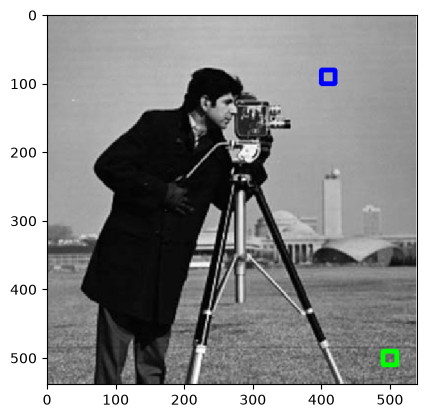

In [1]:
# En primer lugar, obtenemos la máscara de la imagen original mediante la␣umbralización con Otsu
import matplotlib.pyplot as plt
import cv2
import numpy as np
img = cv2.imread('images/photographer.png')
window = cv2.rectangle(img.copy(), (400,80), (420,100), (0, 0, 255), 5)
window = cv2.rectangle(window, (490,490), (510,510), (0, 255, 0), 5)
plt.imshow(window, cmap='gray')
plt.show()


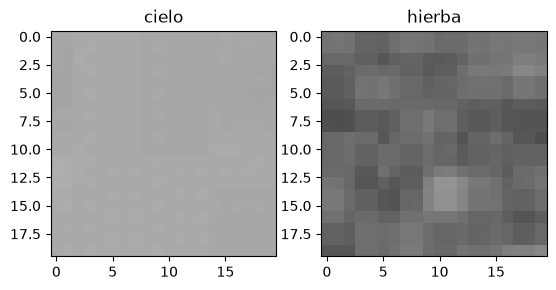

In [2]:
# Seleccionamos una región del cielo y una de la hierba
cielo = img[80:100, 400:420]
hierba = img[490:510, 490:510]
fig, ax = plt.subplots(1,2)
ax[0].imshow(cielo, cmap='gray')
ax[0].set_title('cielo')
ax[1].imshow(hierba, cmap='gray')
ax[1].set_title('hierba')
plt.show()


0.0.1 MATRIZ DE COOCURRENCIA


In [4]:
# MATRIZ DE COOCURRENCIA (Gray-Level Co-occurrence Matrix - GLCM)

from tabulate import tabulate
from skimage.feature import graycomatrix, graycoprops
import cv2
import numpy as np

headers = ['', 'cielo', 'hierba']

CN = ['Contraste']
DIS = ['Disimilitud']
H = ['Homogeneidad']
ASM = ['ASM']
E = ['Energía']
COR = ['Correlación']

patches = []

patches.append(cielo)
patches.append(hierba)

for i in range(len(patches)):

    # Convertir a escala de grises
    image = cv2.cvtColor(patches[i], cv2.COLOR_BGR2GRAY)

    # Crear matriz GLCM
    glcm = graycomatrix(
        image,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    # Extraer características
    CN.append(np.round(graycoprops(glcm, 'contrast')[0,0], 4))
    DIS.append(np.round(graycoprops(glcm, 'dissimilarity')[0,0], 4))
    H.append(np.round(graycoprops(glcm, 'homogeneity')[0,0], 4))
    ASM.append(np.round(graycoprops(glcm, 'ASM')[0,0], 4))
    E.append(np.round(np.sqrt(ASM[-1]), 4))
    COR.append(np.round(graycoprops(glcm, 'correlation')[0,0], 4))


# Mostrar resultados
tabla = [
    CN,
    DIS,
    H,
    ASM,
    E,
    COR
]

print(tabulate(tabla, headers=headers))

                cielo    hierba
------------  -------  --------
Contraste      2        62.8421
Disimilitud    0.8421    5.4211
Homogeneidad   0.6877    0.3466
ASM            0.1982    0.0087
Energía        0.4452    0.0933
Correlación    0.5895    0.7971


0.0.2 Scale-Invariant Feature Transform

(1672, 128)


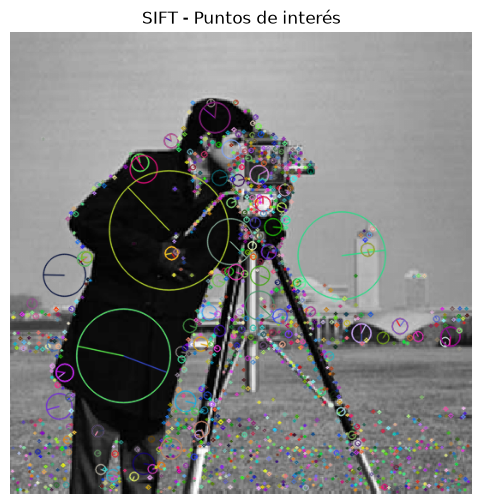

In [8]:
# SIFT algorithm

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer imagen
img = cv2.imread("images/photographer.png")

# Crear algoritmo SIFT
sift = cv2.SIFT_create()

# Detectar puntos de interés
kp = sift.detect(img, None)

# Extraer descriptores
kp, des = sift.compute(img, kp)

# Mostrar tamaño de la matriz de descriptores
print(np.shape(des))

# Dibujar puntos de interés
img_sift = cv2.drawKeypoints(
    img,
    kp,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Convertir para visualizar correctamente con matplotlib
img_sift = cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB)

# Mostrar imagen
plt.figure(figsize=(8,6))
plt.imshow(img_sift)
plt.title("SIFT - Puntos de interés")
plt.axis("off")
plt.show()

0.0.3 Histogram of Oriented Gradients

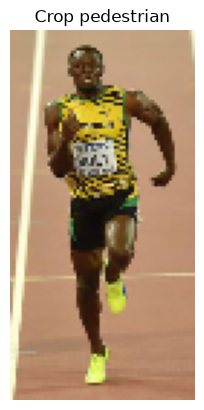

In [10]:
# HISTOGRAM OF ORIENTED GRADIENTS (HOG)

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer imagen
img = cv2.imread("images/pedestrian.jpg")

# Convertir BGR a RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Normalizar imagen
img = np.float32(img / 255)

# Recortar región del peatón
crop = img[75:550, 475:700]

# Redimensionar a tamaño requerido por HOG
crop = cv2.resize(crop, (64, 128))

# Mostrar imagen recortada
plt.imshow(crop)
plt.title("Crop pedestrian")
plt.axis("off")
plt.show()

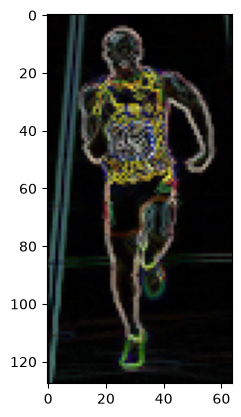

In [11]:
# Calculamos el gradiente con el kernel de Sobel
crop = np.float32(crop)
gx = cv2.Sobel(crop, cv2.CV_32F, 1, 0, ksize=1)
gy = cv2.Sobel(crop, cv2.CV_32F, 0, 1, ksize=1)
# Calculamos la magnitud y la dirección del gradiente
mag, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)
# Visualizamos la imagen obtenida en la magnitud del gradiente
mag = mag/np.max(mag)
plt.imshow(mag, cmap='gray')
plt.show()


In [13]:
# Cálculo del descriptor: Histogram of Oriented Gradients (HOG)

from skimage.feature import hog
import numpy as np

# Calcular descriptor HOG
H = hog(
    crop,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    transform_sqrt=True,
    block_norm="L1",
    channel_axis=-1
)

# Mostrar tamaño del descriptor
print(np.shape(H))

(3780,)


0.0.4 Local Binary Patterns

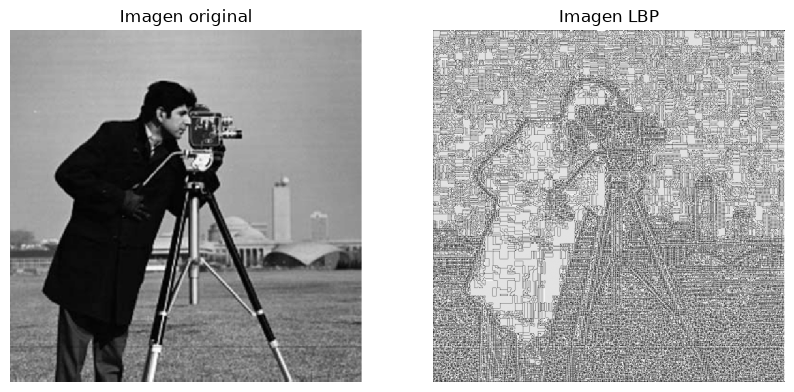

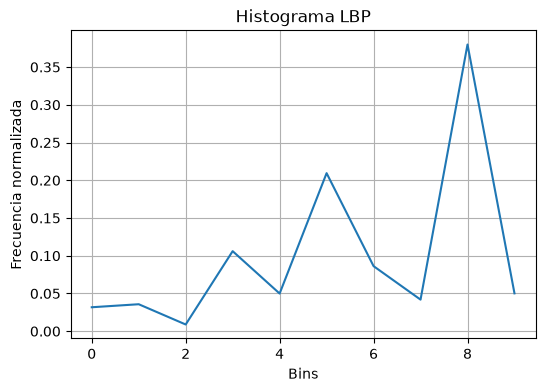

In [15]:
# LOCAL BINARY PATTERNS (LBP)

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern

# Leer imagen
img = cv2.imread("images/photographer.png")

# Verificar si la imagen existe
if img is None:
    print("No se encontró la imagen")
else:

    # Parámetros iniciales
    R = 1              # Radio
    P = 8 * R          # Número de vecinos
    epsilon = 1e-7     # Para evitar división entre cero

    # Convertir a escala de grises
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Calcular LBP
    lbp_image = local_binary_pattern(
        img_gray,
        P,
        R,
        method="uniform"
    )

    # Valores únicos y frecuencia
    a, b = np.unique(lbp_image, return_counts=True)

    # Convertir a uint8
    lbp_image = np.uint8(lbp_image)

    # Calcular histograma
    hist = cv2.calcHist(
        [lbp_image],
        [0],
        None,
        [P + 2],
        [0, P + 2]
    )

    # Normalizar histograma
    hist = hist.astype("float")
    hist /= (hist.sum() + epsilon)

    # Mostrar imágenes
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(img_rgb)
    ax[0].set_title("Imagen original")
    ax[0].axis("off")

    ax[1].imshow(lbp_image, cmap="gray")
    ax[1].set_title("Imagen LBP")
    ax[1].axis("off")

    plt.show()

    # Mostrar histograma
    plt.figure(figsize=(6,4))
    plt.plot(hist)
    plt.title("Histograma LBP")
    plt.xlabel("Bins")
    plt.ylabel("Frecuencia normalizada")
    plt.grid(True)
    plt.show()